In [7]:
import torch
import matplotlib.pyplot as plt
import math

# 1D Viscous Burgers Equation with PyTorch

We solve the one-dimensional viscous Burgers equation

$$
\partial_t u + u\partial_x u = \nu \partial_{xx}u
$$

on the spatial domain

$$
-1 < x < 1
$$

with zero boundary conditions

$$
u(t,-1)=0, \qquad u(t,1)=0
$$

and initial condition

$$
u(0,x) = -\sin(\pi x).
$$

Unlike the heat equation example, we do **not** use an exact solution here.
The goal is to solve the PDE numerically using the finite difference method (FDM).

## Configuration of grid and time

We discretize the spatial domain and choose a time step satisfying simple explicit-method stability conditions:

$$
\frac{\max |u|\Delta t}{\Delta x} \leq C, \qquad
\frac{\nu\Delta t}{\Delta x^2} \leq \frac{1}{2}.
$$

The first condition controls the nonlinear convection term, and the second condition controls the diffusion term.

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# viscosity
nu = 0.01 / torch.pi

# domain and final time
x_min = -1.0
x_max =  1.0
T     = 1.0

# spatial grid
Nx = 201
dx = (x_max - x_min) / (Nx - 1)
x  = torch.linspace(x_min, x_max, Nx, device=device)

# initial condition, used only for choosing a safe time step
u0 = -torch.sin(torch.pi * x)
u0[0]  = 0.0
u0[-1] = 0.0

max_speed0 = torch.max(torch.abs(u0)).item()

# simple stability parameters
CFL = 0.4
r_target = 0.4

dt_convection = CFL * dx / max_speed0
dt_diffusion  = r_target * dx**2 / nu

dt_raw = min(dt_convection, dt_diffusion)
Nt = math.ceil(T / dt_raw)
dt = T / Nt

r = nu * dt / dx**2
cfl_number = max_speed0 * dt / dx

print("device:", device)
print("nu =", nu.item() if torch.is_tensor(nu) else nu)
print("dx =", dx)
print("dt =", dt)
print("Nt =", Nt)
print("CFL number =", cfl_number)
print("r = nu*dt/dx^2 =", r.item() if torch.is_tensor(r) else r)

# set x_grid for plotting
x_cpu = x.detach().cpu().numpy()

device: cuda
nu = 0.003183098861837907
dx = 0.01
dt = 0.004
Nt = 250
CFL number = 0.4
r = nu*dt/dx^2 = 0.12732395447351627


# FDM Update Rule for the 1D Burgers Equation

The 1D viscous Burgers equation is

$$
\partial_t u + u\partial_x u = \nu \partial_{xx}u.
$$

Equivalently,

$$
\partial_t u = -u\partial_x u + \nu \partial_{xx}u.
$$

For the time derivative, we use forward Euler:

$$
\partial_t u \approx \frac{u_i^{n+1}-u_i^n}{\Delta t}.
$$

For the diffusion term, we use the centered second difference:

$$
\partial_{xx}u_i^n
\approx
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}.
$$

For the nonlinear convection term, we use an upwind difference:

$$
D_x^{\mathrm{up}}u_i^n
=
\begin{cases}
\dfrac{u_i^n-u_{i-1}^n}{\Delta x}, & u_i^n \geq 0, \\
\dfrac{u_{i+1}^n-u_i^n}{\Delta x}, & u_i^n < 0.
\end{cases}
$$

Therefore, the explicit update rule is

$$
u_i^{n+1}
=
u_i^n
-
\Delta t\,u_i^nD_x^{\mathrm{up}}u_i^n
+
\nu\Delta t
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}.
$$

The upwind choice is useful because the direction of information flow depends on the sign of $u_i^n$.

## Initial condition

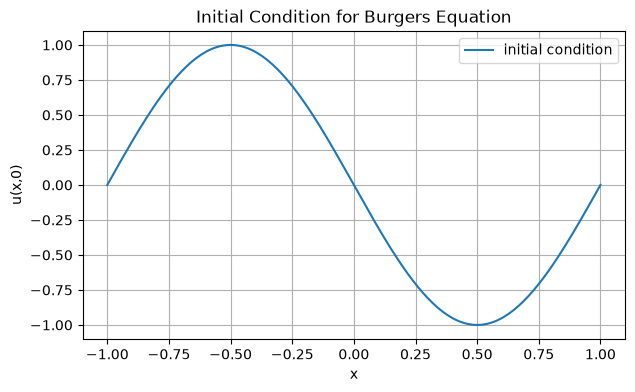

In [9]:
# initial condition
u = -torch.sin(torch.pi * x)

# boundary conditions: u(t,-1)=u(t,1)=0
u[0]  = 0.0
u[-1] = 0.0

plt.figure(figsize=(7, 4))
plt.plot(x_cpu, u.detach().cpu().numpy(), label="initial condition")
plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.title("Initial Condition for Burgers Equation")
plt.legend()
plt.grid(True)
plt.show()

# Solve Burgers Equation by Explicit FDM

We iterate over time steps. At each step:

1. copy the current solution,
2. compute the upwind approximation of $u_x$,
3. compute the centered approximation of $u_{xx}$,
4. update the interior grid points,
5. impose the boundary conditions.

In [10]:
# reset initial condition
u = -torch.sin(torch.pi * x)
u[0]  = 0.0
u[-1] = 0.0

# store selected solution snapshots
u_history = []
t_history = []

# store more snapshots for the heat-map style visualization
u_map_history = []
t_map_history = []

num_snapshots = 6
save_steps = sorted(set(int(round(s)) for s in torch.linspace(0, Nt, num_snapshots).tolist()))
map_save_every = max(1, Nt // 200)

for n in range(Nt + 1):

    # current time
    t_now = n * dt

    # save selected snapshots
    if n in save_steps:
        u_history.append(u.detach().cpu().clone())
        t_history.append(t_now)

    # save for heat-map style plot
    if n % map_save_every == 0 or n == Nt:
        u_map_history.append(u.detach().cpu().clone())
        t_map_history.append(t_now)

    # no update after final time
    if n == Nt:
        break

    # copy current solution
    u_old = u.clone()

    # interior values
    u_center = u_old[1:-1]

    # upwind first derivative
    u_x_backward = (u_old[1:-1] - u_old[:-2]) / dx
    u_x_forward  = (u_old[2:] - u_old[1:-1]) / dx
    u_x_upwind   = torch.where(u_center >= 0, u_x_backward, u_x_forward)

    # centered second derivative
    u_xx = (u_old[2:] - 2 * u_old[1:-1] + u_old[:-2]) / dx**2

    # explicit FDM update
    u[1:-1] = u_old[1:-1] - dt * u_center * u_x_upwind + nu * dt * u_xx

    # boundary conditions
    u[0]  = 0.0
    u[-1] = 0.0

print("number of saved snapshots:", len(u_history))
print("saved times:", [round(t, 3) for t in t_history])

number of saved snapshots: 6
saved times: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


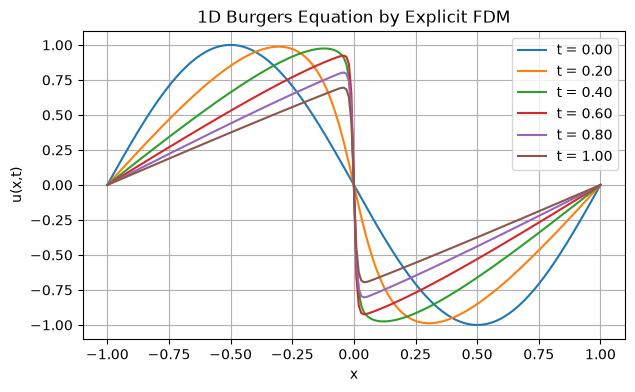

In [11]:
# -----------------------
# Plot selected FDM snapshots
# -----------------------

plt.figure(figsize=(7, 4))

for t_now, u_snapshot in zip(t_history, u_history):
    plt.plot(
        x_cpu,
        u_snapshot.numpy(),
        label=f"t = {t_now:.2f}",
    )

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("1D Burgers Equation by Explicit FDM")
plt.legend()
plt.grid(True)
plt.show()

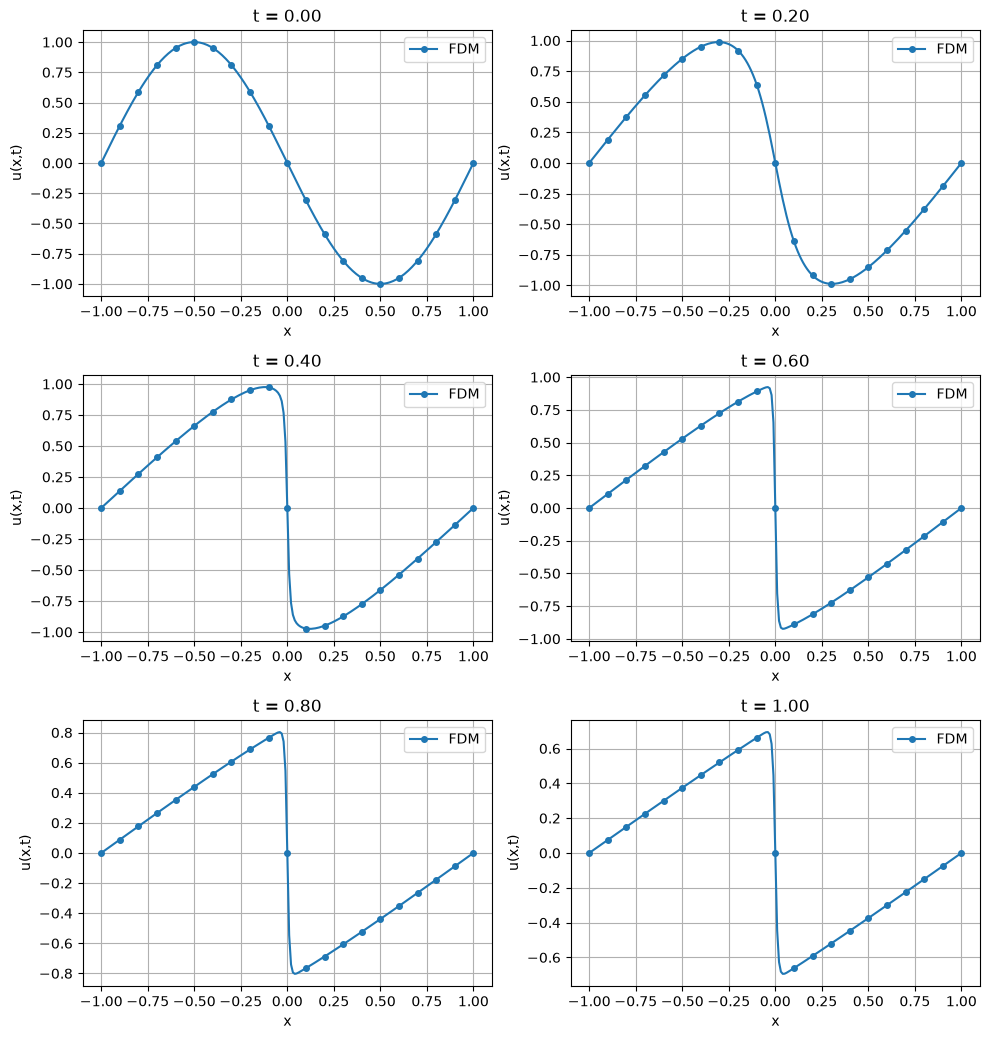

In [12]:
# -----------------------
# Plot selected FDM snapshots using subplots
# -----------------------

num_plots = len(t_history)

# choose subplot layout
ncols = 2
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))

# make axes always iterable
axes = axes.flatten()

for k, (t_now, u_snapshot) in enumerate(zip(t_history, u_history)):

    ax = axes[k]

    ax.plot(
        x_cpu,
        u_snapshot.numpy(),
        "-o",
        markevery=10,
        markersize=4,
        label="FDM",
    )

    ax.set_title(f"t = {t_now:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.grid(True)
    ax.legend()

# hide unused subplot axes
for j in range(num_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

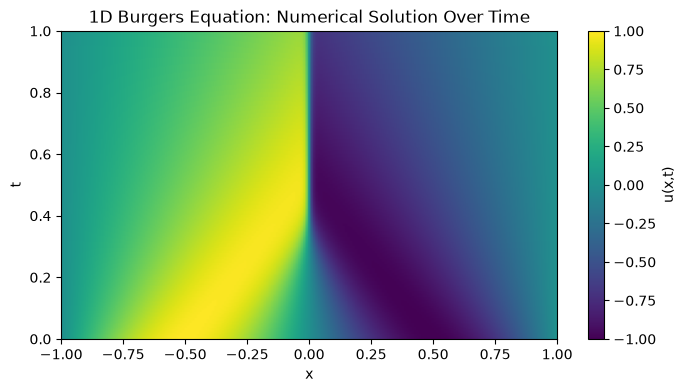

In [13]:
# -----------------------
# Heat-map style visualization of the numerical solution
# -----------------------

u_map = torch.stack(u_map_history)  # shape: [time, x]

plt.figure(figsize=(8, 4))
plt.imshow(
    u_map.numpy(),
    extent=[x_min, x_max, t_map_history[0], t_map_history[-1]],
    aspect="auto",
    origin="lower",
)

plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("1D Burgers Equation: Numerical Solution Over Time")
plt.show()

## What to observe

Compared with the heat equation, Burgers equation has two effects:

- the nonlinear convection term $u\partial_x u$ moves and steepens the solution profile,
- the diffusion term $\nu\partial_{xx}u$ smooths the solution profile.

Because of this nonlinear convection, obtaining a simple exact solution is difficult. Therefore, this example focuses on the numerical FDM solution.